<a href="https://colab.research.google.com/github/dogyeong06/2026_tues_bigatacomputing_class/blob/main/%EB%B9%85%EB%8D%B0%EC%9D%B4%ED%84%B0_%EA%B8%B0%EB%A7%90_%EA%B3%BC%EC%A0%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
import joblib

# 1. 데이터 로드 및 전처리
url = 'https://github.com/dongupak/DataML/raw/main/csv/life_expectancy.csv'
df = pd.read_csv(url)
df = df.dropna()

# 컬럼명 앞뒤 공백 제거
df.columns = df.columns.str.strip()

# 특성 3개 자율 선택 (Schooling 제외) 및 타겟 설정
features = ['BMI', 'GDP', 'Alcohol']
target = 'Life expectancy'

X = df[features]
y = df[target]

# 2. 데이터 분할 및 50개 훈련 샘플링 (과대적합 유도)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train_50 = X_train.sample(n=50, random_state=42)
y_train_50 = y_train.loc[X_train_50.index]

# 나중에 웹 앱에서 성능 비교를 위해 분할된 데이터도 함께 저장
joblib.dump((X_train_50, X_test, y_train_50, y_test), 'data_split.pkl')

# 3. 파이프라인 기반 모델 3종 구축 및 학습
# Model 1 (Linear)
model_linear = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])
model_linear.fit(X_train_50, y_train_50)

# Model 2 (Poly)
model_poly = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=3)),
    ('regressor', LinearRegression())
])
model_poly.fit(X_train_50, y_train_50)

# Model 3 (Ridge)
model_ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=3)),
    ('regressor', Ridge(alpha=1.0))
])
model_ridge.fit(X_train_50, y_train_50)

# 4. 모델 저장
joblib.dump(model_linear, 'model_linear.pkl')
joblib.dump(model_poly, 'model_poly.pkl')
joblib.dump(model_ridge, 'model_ridge.pkl')
print("✅ 데이터 및 모델 3종 저장 완료!")

✅ 데이터 및 모델 3종 저장 완료!


In [2]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score
import joblib

# 페이지 기본 설정
st.set_page_config(page_title="기대수명 예측 대시보드", layout="wide")
st.title("🌍 다중 특성 회귀 기대수명 예측 서비스")

# 데이터 및 모델 로드
@st.cache_resource
def load_assets():
    X_train, X_test, y_train, y_test = joblib.load('data_split.pkl')
    models = {
        'Linear': joblib.load('model_linear.pkl'),
        'Poly': joblib.load('model_poly.pkl'),
        'Ridge': joblib.load('model_ridge.pkl')
    }
    return X_train, X_test, y_train, y_test, models

X_train, X_test, y_train, y_test, models = load_assets()

# 모델 성능 평가
results = []
for name, model in models.items():
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    # 특성 개수(Complexity) 계산
    if name == 'Linear':
        complexity = X_train.shape[1]
    else:
        complexity = model.named_steps['poly'].transform(model.named_steps['scaler'].transform(X_train)).shape[1]

    results.append({
        'Model': name,
        'Train R²': train_r2,
        'Test R²': test_r2,
        'Train MSE': train_mse,
        'Test MSE': test_mse,
        'Complexity': complexity
    })

df_results = pd.DataFrame(results).set_index('Model')

# 화면 구성: 2단 분할
col1, col2 = st.columns(2)

with col1:
    st.subheader("📊 모델 성능 비교 테이블")
    st.dataframe(df_results.style.highlight_max(subset=['Test R²'], color='lightgreen'))

with col2:
    st.subheader("📈 Test R² Score 비교 막대그래프")
    fig, ax = plt.subplots(figsize=(6, 4))
    sns.barplot(x=df_results.index, y=df_results['Test R²'], ax=ax, palette='viridis')
    ax.set_ylabel('Test R² Score')
    st.pyplot(fig)

st.divider()

# 사이드바 입력창 구성
st.sidebar.header("🎛️ 실시간 예측 패널")
selected_model = st.sidebar.selectbox("모델 선택", ["Linear", "Poly", "Ridge"])

st.sidebar.subheader("특성 수치 조절")
input_data = {}
for col in X_train.columns:
    # 훈련 데이터의 최소/최대/평균값을 기반으로 슬라이더 생성
    min_val = float(X_train[col].min())
    max_val = float(X_train[col].max())
    mean_val = float(X_train[col].mean())
    input_data[col] = st.sidebar.slider(f"{col}", min_val, max_val, mean_val)

# 실시간 예측 및 출력
input_df = pd.DataFrame([input_data])
prediction = models[selected_model].predict(input_df)[0]

st.subheader("🎯 실시간 예측 결과")
st.markdown(f"선택한 모델 (**{selected_model}**)을 기반으로 예측된 기대수명입니다.")
st.metric(label="예측 수명", value=f"{prediction:.2f} 세")

Writing app.py


In [3]:
# 필수 라이브러리 설치
!pip install -q streamlit pyngrok

# 백그라운드에서 Streamlit 실행
import subprocess
subprocess.Popen(["streamlit", "run", "app.py"])

# ngrok을 통한 터널링 및 URL 출력
from pyngrok import ngrok

# 기존에 연결된 포트가 있다면 종료
ngrok.kill()

# 전달해주신 ngrok Auth Token 설정
ngrok.set_auth_token("3EZPig8e2ra72jPb3iHx0Ls4Yow_RFYYjvZqudcJX5xjx64W")

# 포트 8501 연결 (Streamlit 기본 포트)
public_url = ngrok.connect(8501)
print(f"🌐 접속 URL: {public_url}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 36.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 68.0 MB/s eta 0:00:00
🌐 접속 URL: NgrokTunnel: "https://reliably-eloquent-emphasis.ngrok-free.dev" -> "http://localhost:8501"


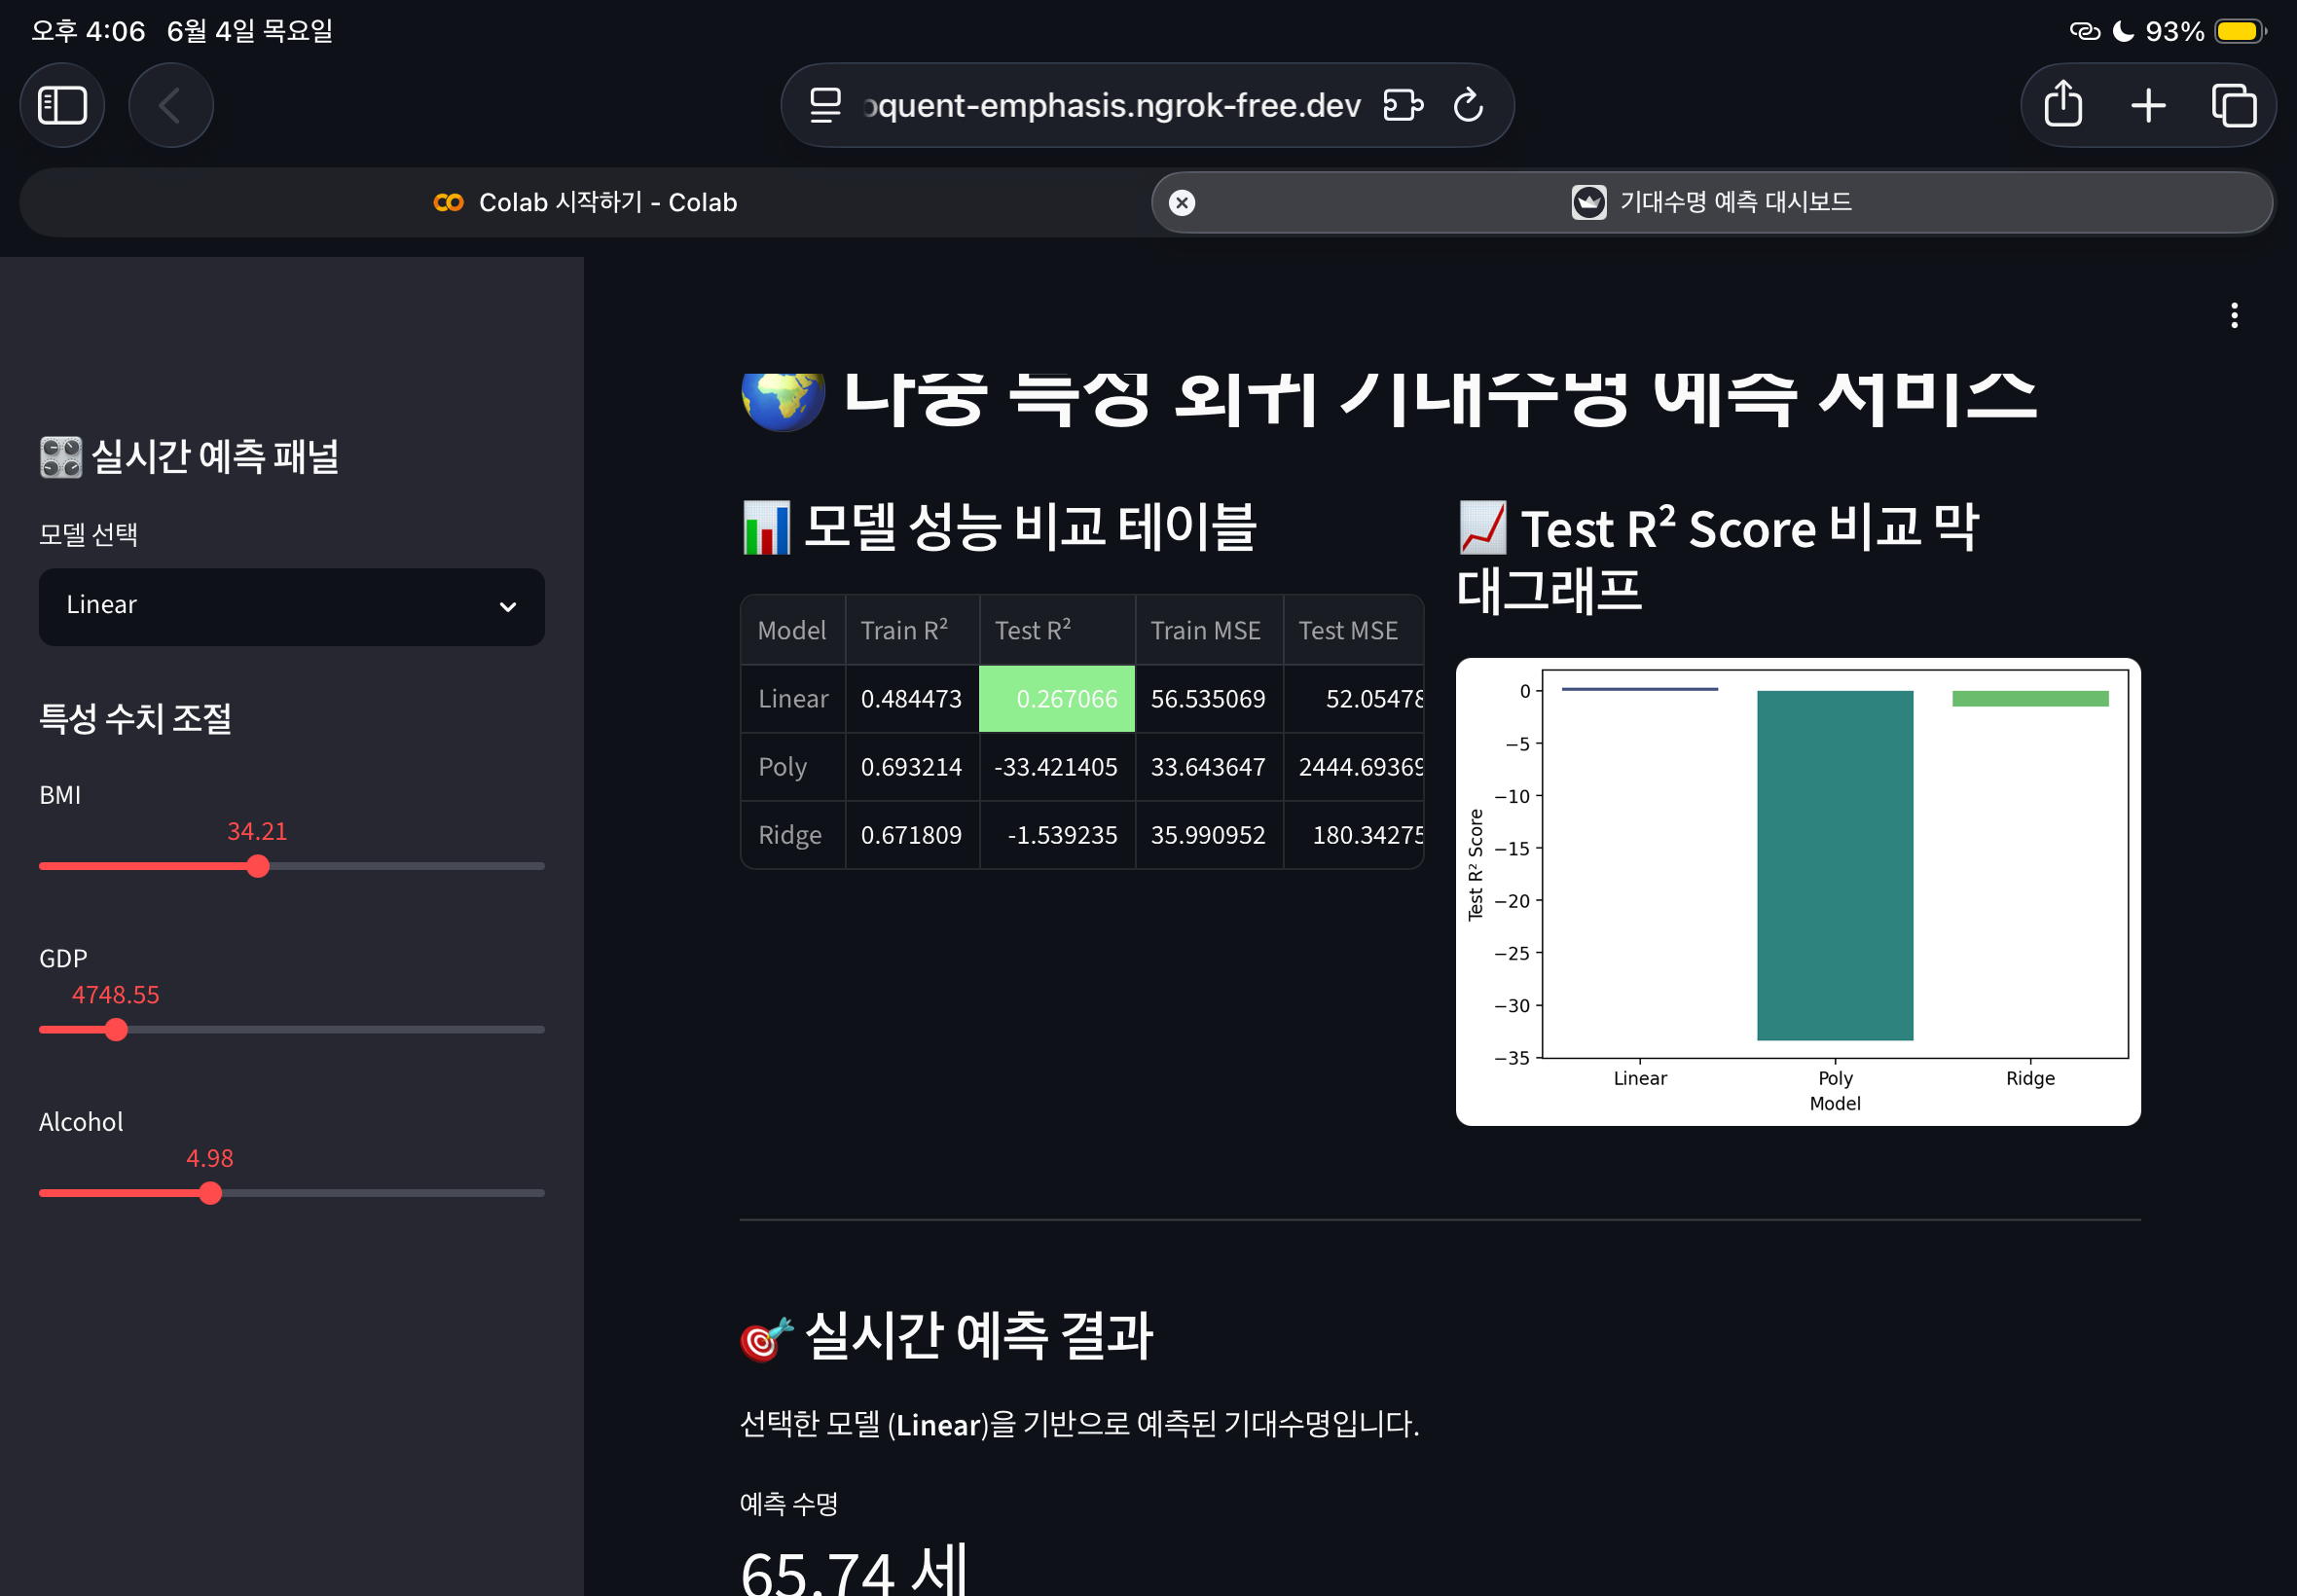